In [8]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil
import torch
from torchvision import models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import lr_scheduler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import time
import copy

## Data Loading & PreProcessing

Classes found: ['Bacterial Leaf Blight', 'Brown Spot', 'Healthy Rice Leaf', 'Leaf Blast', 'Leaf scald', 'Sheath Blight']
Using classes: ['Healthy Rice Leaf', 'Leaf Blast', 'Brown Spot', 'Leaf scald']

Split completed successfully!


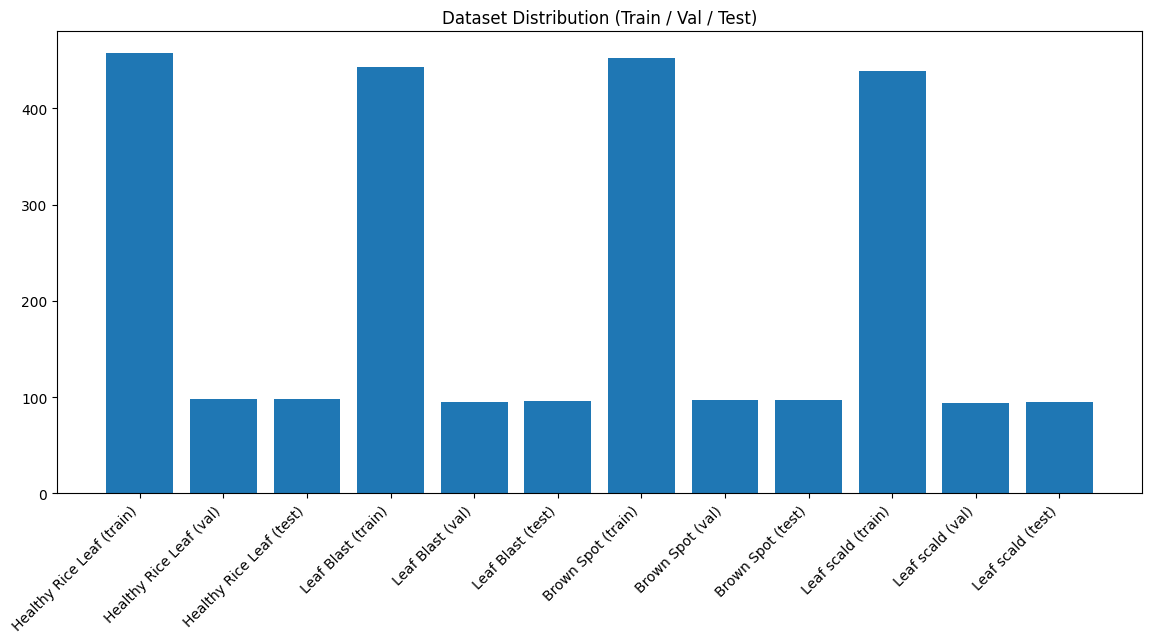

In [2]:
DATASET_PATH = "/kaggle/input/rice-disease-dataset/Rice_Leaf_AUG"


all_classes = sorted([d for d in os.listdir(DATASET_PATH) 
                      if os.path.isdir(os.path.join(DATASET_PATH, d))])

print("Classes found:", all_classes)

selected_classes = [
    "Healthy Rice Leaf",
    "Leaf Blast",
    "Brown Spot",
    "Leaf scald"
]

print("Using classes:", selected_classes)


OUTPUT_DIR = "/kaggle/working/split_data"
splits = ["train", "val", "test"]

for split in splits:
    for cls in selected_classes:
        os.makedirs(f"{OUTPUT_DIR}/{split}/{cls}", exist_ok=True)


def split_images(class_path):
    imgs = [f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg",".jpeg",".png"))]

    train, temp = train_test_split(imgs, test_size=0.30, random_state=42)
    val, test = train_test_split(temp, test_size=0.50, random_state=42)

    return train, val, test


class_counts = {}

for cls in selected_classes:
    folder = os.path.join(DATASET_PATH, cls)

    train_imgs, val_imgs, test_imgs = split_images(folder)

    class_counts[cls] = {
        "train": len(train_imgs),
        "val": len(val_imgs),
        "test": len(test_imgs)
    }

    for img in train_imgs:
        shutil.copy(os.path.join(folder, img),
                    f"{OUTPUT_DIR}/train/{cls}/{img}")

    for img in val_imgs:
        shutil.copy(os.path.join(folder, img),
                    f"{OUTPUT_DIR}/val/{cls}/{img}")

    for img in test_imgs:
        shutil.copy(os.path.join(folder, img),
                    f"{OUTPUT_DIR}/test/{cls}/{img}")

print("\nSplit completed successfully!")

# Plotting
labels = []
counts = []

for cls in selected_classes:
    for split in ["train","val","test"]:
        labels.append(f"{cls} ({split})")
        counts.append(class_counts[cls][split])

plt.figure(figsize=(14,6))
plt.bar(labels, counts)
plt.xticks(rotation=45, ha='right')
plt.title("Dataset Distribution (Train / Val / Test)")
plt.show()


Classes: ['Brown Spot', 'Healthy Rice Leaf', 'Leaf Blast', 'Leaf scald']
Dataset sizes: {'train': 1791, 'val': 384, 'test': 386}


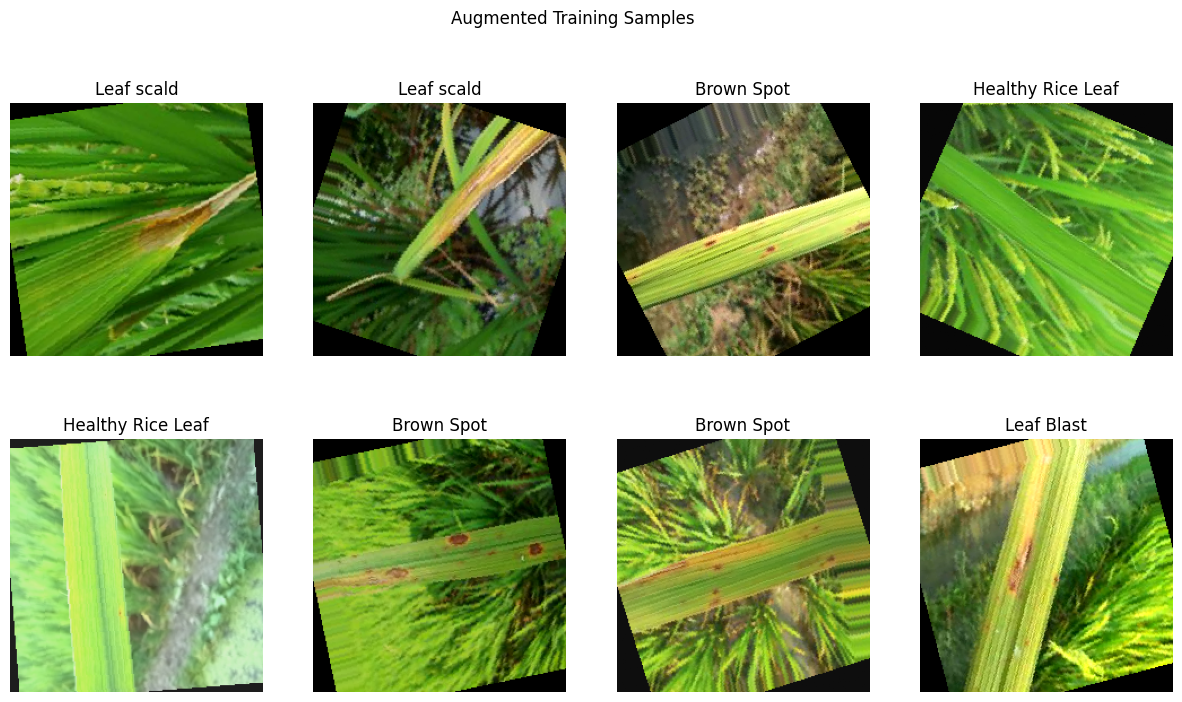

In [3]:
# ToTensor() automatically converts images to range [0, 1]

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        # --- Augmentation (At least 3 methods) ---
        transforms.RandomRotation(30),      # 1. Rotation
        transforms.RandomHorizontalFlip(),  # 2. Flip
        transforms.ColorJitter(brightness=0.2, contrast=0.2), # 3. Color/Brightness change
        # -----------------------------------------
        transforms.ToTensor()  # Converts [0, 255] -> [0, 1]
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ]),
}


DATA_DIR = "/kaggle/working/split_data"

image_datasets = {x: datasets.ImageFolder(root=f"{DATA_DIR}/{x}",
                                          transform=data_transforms[x])
                  for x in ['train', 'val', 'test']}

dataloaders = {x: DataLoader(image_datasets[x], batch_size=32,
                             shuffle=(x == 'train'), num_workers=2)
               for x in ['train', 'val', 'test']}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes

print(f"Classes: {class_names}")
print(f"Dataset sizes: {dataset_sizes}")

# some augmented samples
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0)) # Convert (C, H, W) -> (H, W, C)
    plt.imshow(inp)
    if title:
        plt.title(title)
    plt.axis('off')

inputs, classes = next(iter(dataloaders['train']))

plt.figure(figsize=(15, 8))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    imshow(inputs[i], title=class_names[classes[i]])
plt.suptitle("Augmented Training Samples")
plt.show()


# 3.1: ALEXNET

In [4]:
# We use standard ImageNet normalization stats which usually work better
# than just 0-1 scaling for CNNs.
norm_mean = [0.485, 0.456, 0.406]
norm_std = [0.229, 0.224, 0.225]

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(30),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.2),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize(norm_mean, norm_std)
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(norm_mean, norm_std)
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(norm_mean, norm_std)
    ]),
}

# Re-load datasets with these new transforms
image_datasets = {x: datasets.ImageFolder(root=f"{DATA_DIR}/{x}",
                                          transform=data_transforms[x])
                  for x in ['train', 'val', 'test']}

dataloaders = {x: DataLoader(image_datasets[x], batch_size=32,
                             shuffle=(x == 'train'), num_workers=2)
               for x in ['train', 'val', 'test']}

# ALEXNET
class AlexNetCustom(nn.Module):
    def __init__(self, num_classes=4):
        super(AlexNetCustom, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


model_alex = AlexNetCustom(num_classes=4)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_alex = model_alex.to(device)

criterion = nn.CrossEntropyLoss()

# Weight decay helps prevent the model from memorizing the training data too fast
optimizer = optim.Adam(model_alex.parameters(), lr=0.0001, weight_decay=1e-4)


exp_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

num_epochs = 30 

# Training
def train_model_improved(model, dataloaders, criterion, optimizer, scheduler, num_epochs=30):
    since = time.time()
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best Val Acc: {best_acc:.4f}')

    model.load_state_dict(best_model_wts)
    return model, history

# Run training
trained_alexnet, history = train_model_improved(
    model_alex, dataloaders, criterion, optimizer, exp_lr_scheduler, num_epochs=num_epochs
)


Epoch 1/30
----------
train Loss: 1.1950 Acc: 0.4478
val Loss: 0.9451 Acc: 0.6094

Epoch 2/30
----------
train Loss: 0.8834 Acc: 0.6248
val Loss: 0.8008 Acc: 0.6510

Epoch 3/30
----------
train Loss: 0.8233 Acc: 0.6611
val Loss: 0.7573 Acc: 0.7083

Epoch 4/30
----------
train Loss: 0.7204 Acc: 0.7136
val Loss: 0.8016 Acc: 0.6719

Epoch 5/30
----------
train Loss: 0.6695 Acc: 0.7314
val Loss: 0.6421 Acc: 0.7396

Epoch 6/30
----------
train Loss: 0.6299 Acc: 0.7437
val Loss: 0.6935 Acc: 0.7292

Epoch 7/30
----------
train Loss: 0.5927 Acc: 0.7672
val Loss: 0.5978 Acc: 0.7682

Epoch 8/30
----------
train Loss: 0.4995 Acc: 0.8068
val Loss: 0.5296 Acc: 0.7943

Epoch 9/30
----------
train Loss: 0.4686 Acc: 0.8146
val Loss: 0.5024 Acc: 0.8073

Epoch 10/30
----------
train Loss: 0.4648 Acc: 0.8096
val Loss: 0.4947 Acc: 0.8125

Epoch 11/30
----------
train Loss: 0.4671 Acc: 0.8174
val Loss: 0.4781 Acc: 0.8099

Epoch 12/30
----------
train Loss: 0.4405 Acc: 0.8208
val Loss: 0.4888 Acc: 0.8151

E

# 3.2

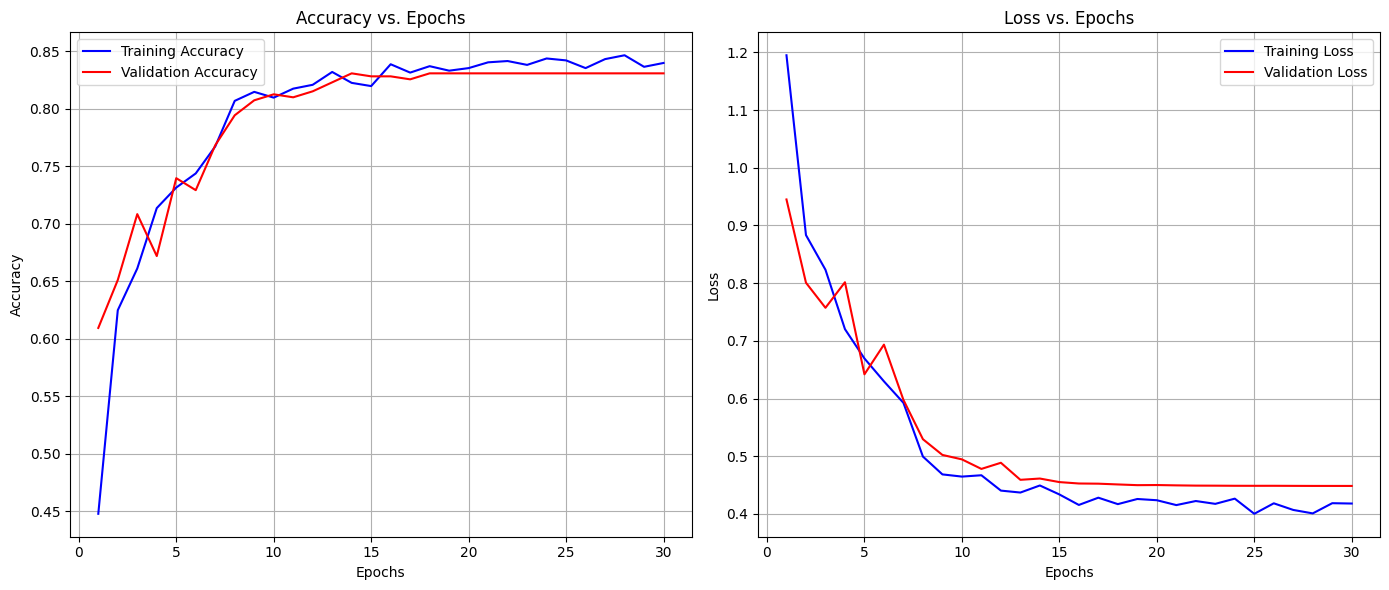


PERFORMANCE METRICS (Table 4 Style)
               Class  TP   TN  FP  FN  Accuracy  Sensitivity  Specificity
0         Brown Spot  79  260  29  18    0.8782       0.8144       0.8997
1  Healthy Rice Leaf  91  284   4   7    0.9715       0.9286       0.9861
2         Leaf Blast  58  279  11  38    0.8731       0.6042       0.9621
3         Leaf scald  83  260  31  12    0.8886       0.8737       0.8935

------------------------------
Average Accuracy:    0.9028
Average Sensitivity: 0.8052
Average Specificity: 0.9353
------------------------------


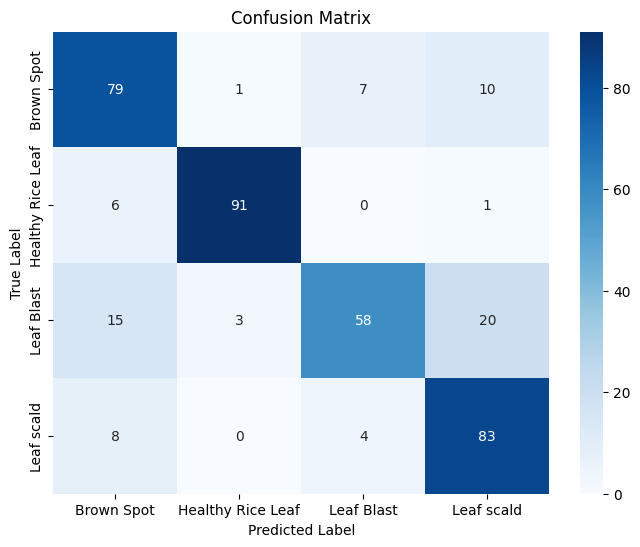

In [6]:
# Plotting
def plot_training_history(history):
    epochs = range(1, len(history['train_acc']) + 1)
    
    plt.figure(figsize=(14, 6))
    
    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_acc'], 'b-', label='Training Accuracy')
    plt.plot(epochs, history['val_acc'], 'r-', label='Validation Accuracy')
    plt.title('Accuracy vs. Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_loss'], 'b-', label='Training Loss')
    plt.plot(epochs, history['val_loss'], 'r-', label='Validation Loss')
    plt.title('Loss vs. Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

# Execute Plotting
plot_training_history(history)

# Metrics
def evaluate_performance(model, dataloader, class_names):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    # 1. Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    # Sensitivity = TP / (TP + FN)
    # Specificity = TN / (TN + FP)
    
    FP = cm.sum(axis=0) - np.diag(cm)  
    FN = cm.sum(axis=1) - np.diag(cm)
    TP = np.diag(cm)
    TN = cm.sum() - (FP + FN + TP)

    sensitivity = TP / (TP + FN + 1e-10) # Add epsilon to avoid div by zero
    specificity = TN / (TN + FP + 1e-10)
    accuracy = (TP + TN) / (TP + TN + FP + FN + 1e-10)
    
    results_df = pd.DataFrame({
        'Class': class_names,
        'TP': TP,
        'TN': TN,
        'FP': FP,
        'FN': FN,
        'Accuracy': accuracy,
        'Sensitivity': sensitivity,
        'Specificity': specificity
    })
    
    print("\n" + "="*50)
    print("PERFORMANCE METRICS (Table 4 Style)")
    print("="*50)
    print(results_df.round(4))
    
    print("\n" + "-"*30)
    print(f"Average Accuracy:    {results_df['Accuracy'].mean():.4f}")
    print(f"Average Sensitivity: {results_df['Sensitivity'].mean():.4f}")
    print(f"Average Specificity: {results_df['Specificity'].mean():.4f}")
    print("-"*30)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

class_names = image_datasets['train'].classes

evaluate_performance(trained_alexnet, dataloaders['test'], class_names)


## 4: Paper's Model

Training INC-VGGN Model...
Epoch 1/30
----------
train Loss: 1.3461 Acc: 0.3797
val Loss: 1.2724 Acc: 0.5417

Epoch 2/30
----------
train Loss: 1.1611 Acc: 0.6214
val Loss: 1.0330 Acc: 0.6328

Epoch 3/30
----------
train Loss: 0.9486 Acc: 0.6857
val Loss: 0.8565 Acc: 0.6719

Epoch 4/30
----------
train Loss: 0.7718 Acc: 0.7275
val Loss: 0.7054 Acc: 0.7344

Epoch 5/30
----------
train Loss: 0.6190 Acc: 0.7722
val Loss: 0.5773 Acc: 0.7786

Epoch 6/30
----------
train Loss: 0.5068 Acc: 0.8169
val Loss: 0.5634 Acc: 0.7552

Epoch 7/30
----------
train Loss: 0.4400 Acc: 0.8358
val Loss: 0.4285 Acc: 0.8411

Epoch 8/30
----------
train Loss: 0.3884 Acc: 0.8615
val Loss: 0.3986 Acc: 0.8438

Epoch 9/30
----------
train Loss: 0.3854 Acc: 0.8677
val Loss: 0.3868 Acc: 0.8516

Epoch 10/30
----------
train Loss: 0.3666 Acc: 0.8800
val Loss: 0.3814 Acc: 0.8568

Epoch 11/30
----------
train Loss: 0.3608 Acc: 0.8721
val Loss: 0.3775 Acc: 0.8516

Epoch 12/30
----------
train Loss: 0.3416 Acc: 0.8833
val 

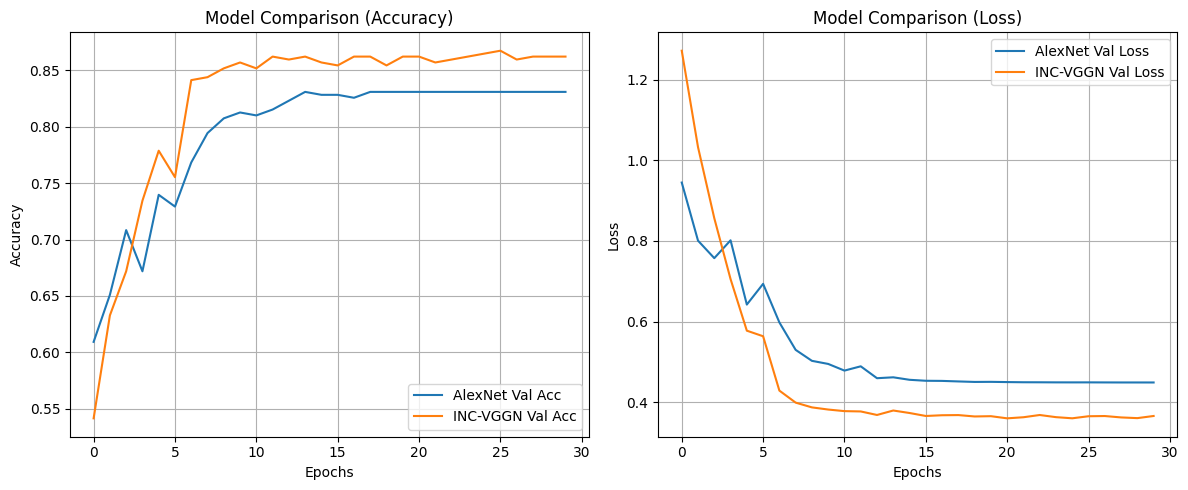


--- Final Evaluation: INC-VGGN ---

PERFORMANCE METRICS (Table 4 Style)
               Class  TP   TN  FP  FN  Accuracy  Sensitivity  Specificity
0         Brown Spot  85  280   9  12    0.9456       0.8763       0.9689
1  Healthy Rice Leaf  98  283   5   0    0.9870       1.0000       0.9826
2         Leaf Blast  74  279  11  22    0.9145       0.7708       0.9621
3         Leaf scald  88  275  16   7    0.9404       0.9263       0.9450

------------------------------
Average Accuracy:    0.9469
Average Sensitivity: 0.8934
Average Specificity: 0.9646
------------------------------


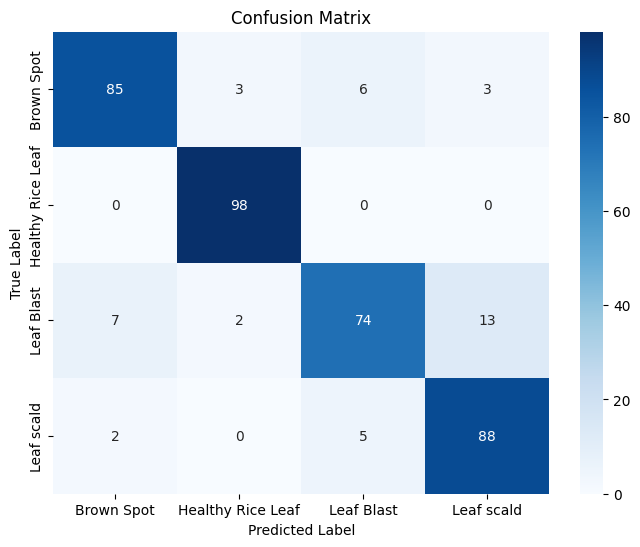

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import copy
import time

class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)


class InceptionModule(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(InceptionModule, self).__init__()
        

        branch_channels = out_channels // 4
        
        # Branch 1: 1x1 conv
        self.branch1 = nn.Conv2d(in_channels, branch_channels, kernel_size=1)
        
        # Branch 2: 1x1 -> 3x3 conv
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels, branch_channels, kernel_size=1),
            nn.BatchNorm2d(branch_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(branch_channels, branch_channels, kernel_size=3, padding=1)
        )
        
        # Branch 3: 1x1 -> 3x3 -> 3x3 (Paper's 5x5 replacement)
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, branch_channels, kernel_size=1),
            nn.BatchNorm2d(branch_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(branch_channels, branch_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(branch_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(branch_channels, branch_channels, kernel_size=3, padding=1)
        )
        
        # Branch 4: 3x3 pool -> 1x1 conv
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, branch_channels, kernel_size=1)
        )

    def forward(self, x):
        b1 = self.branch1(x)
        b2 = self.branch2(x)
        b3 = self.branch3(x)
        b4 = self.branch4(x)
        return torch.cat([b1, b2, b3, b4], 1)

# INC_VGGN
class INC_VGGN(nn.Module):
    def __init__(self, num_classes=4):
        super(INC_VGGN, self).__init__()
        
        # Load VGG19 (ImageNet weights)
        vgg = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)
        
        # KEEP LAYERS UP TO POOL4 (Index 28 is exclusive)
        # Block 1: 0-4
        # Block 2: 5-9
        # Block 3: 10-18
        # Block 4: 19-27 (Conv4_1...Pool4)
        # We keep [0...27], so slice is [:28]
        self.features = nn.Sequential(*list(vgg.features.children())[:28]) 
        
        # Freeze VGG layers
        for param in self.features.parameters():
            param.requires_grad = False
            
        # New Layers per Table 1 of the Paper
        # Input to this block is 512 channels (from VGG Pool4)
        
        # 1. Conv Block with BN + Swish
        self.conv_bn_swish = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            Swish()
        )
        
        # 2. Inception Module 1 (Output 256 channels)
        self.inception1 = InceptionModule(in_channels=512, out_channels=256)
        
        # 3. Inception Module 2 (Output 256 channels)
        self.inception2 = InceptionModule(in_channels=256, out_channels=256)
        
        # 4. Global Pooling
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # 5. Classifier
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.conv_bn_swish(x)
        x = self.inception1(x)
        x = self.inception2(x)
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


DATA_DIR = "/kaggle/working/split_data"

vgg_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(30),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

image_datasets_vgg = {x: datasets.ImageFolder(root=f"{DATA_DIR}/{x}",
                                              transform=vgg_transforms[x])
                      for x in ['train', 'val', 'test']}

dataloaders_vgg = {x: DataLoader(image_datasets_vgg[x], batch_size=32,
                                 shuffle=(x == 'train'), num_workers=2)
                   for x in ['train', 'val', 'test']}

dataset_sizes = {x: len(image_datasets_vgg[x]) for x in ['train', 'val', 'test']}


model_inc = INC_VGGN(num_classes=4)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_inc = model_inc.to(device)

criterion = nn.CrossEntropyLoss()

# Optimizer: Only update new layers
optimizer_inc = optim.SGD(filter(lambda p: p.requires_grad, model_inc.parameters()), 
                          lr=0.001, momentum=0.9)

# Scheduler: Same strategy as AlexNet
exp_lr_scheduler_inc = lr_scheduler.StepLR(optimizer_inc, step_size=7, gamma=0.1)

print("Training INC-VGGN Model...")

trained_inc_vgg, history_inc = train_model_improved(
    model_inc, dataloaders_vgg, criterion, optimizer_inc, exp_lr_scheduler_inc, num_epochs=30
)

# Plotting
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
if 'history' in globals(): 
    plt.plot(history['val_acc'], label='AlexNet Val Acc')
plt.plot(history_inc['val_acc'], label='INC-VGGN Val Acc')
plt.title('Model Comparison (Accuracy)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
if 'history' in globals():
    plt.plot(history['val_loss'], label='AlexNet Val Loss')
plt.plot(history_inc['val_loss'], label='INC-VGGN Val Loss')
plt.title('Model Comparison (Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\n--- Final Evaluation: INC-VGGN ---")
class_names = image_datasets_vgg['train'].classes
evaluate_performance(trained_inc_vgg, dataloaders_vgg['test'], class_names)
